# MAC-Based Systolic Array Accelerator for ML Inference

**Author:** Suliat Saka  
**Institution:** University of Lagos, Electrical and Electronics Engineering  
**Tools:** Icarus Verilog · GTKWave · OpenLane v1.0.2 · Sky130A PDK  
**License:** Apache 2.0
**Email:** fiwealthkemhie@gmail.com

---

## Abstract

This notebook presents a parameterized MAC-based systolic array hardware accelerator
designed for ML inference workloads, implemented in Verilog and synthesized on the
SkyWater 130nm open-source PDK using OpenLane.

The design implements weight-stationary dataflow — the same architectural principle
used in Google's TPU — through a clean three-level hierarchy: MAC unit → Processing
Element → 4x4 Systolic Array. All modules are verified against a Python numpy golden
reference using Icarus Verilog simulation. Physical implementation achieves timing
closure at 50MHz with zero DRC and LVS violations on Sky130A.

The core insight: 80% of ML inference compute is matrix multiplication. In 1978,
Kung and Leiserson showed that a systolic array — data pulsing rhythmically through
a grid of processors like blood through a heart — is the most efficient silicon
implementation of this operation. Google's TPU is a 256×256 systolic array.
This design implements the same primitive at 4×4 scale using fully open-source tools.

## 1. Motivation

### Why matrix multiplication?

80% of ML inference runtime is matrix multiplication. Every neural network layer
is fundamentally a matrix multiply — the input data matrix multiplied by the
learned weight matrix. This is true for CNNs, transformers, and LLMs alike.

### Why a systolic array?

Naive matrix multiply on a CPU fetches data from memory for every computation.
Memory is slow. Compute is fast. The bottleneck is always the bus between them.

In 1978, H.T. Kung and Charles Leiserson published "Systolic Arrays for VLSI"
with a key insight: read each piece of data once, then pass it through a grid
of processors. Each processor does one multiply-accumulate before handing data
to its neighbour. Result: N computations per memory access instead of 1.

For an NxN matrix multiply: N³ operations, N² data elements. Every element
reused N times. The systolic array exploits this reuse directly.

### Industry convergence

Google and NVIDIA independently converged on this architecture:
- **Google TPU**: a 256×256 systolic array — 65,536 MAC units on one die
- **NVIDIA Tensor Cores**: tiny systolic arrays embedded inside each streaming multiprocessor
- On Blackwell, 98% of peak FLOPs come from tensor cores

This design implements the same primitive at 4×4 scale using fully open-source tools.

### Why weight-stationary dataflow?

In ML inference, the same model weights are used for millions of inference requests.
Weight-stationary dataflow loads weights into PE registers once and keeps them fixed.
Only the input activations flow through. This minimises weight memory bandwidth —
the dominant bottleneck for inference workloads. This is the same choice Google
made for TPU v1.



In [ ]:
# Install Icarus Verilog for simulation inside Colab
!apt-get install -y iverilog > /dev/null 2>&1
!iverilog -V 2>&1 | head -1
print("Icarus Verilog installed successfully")

Icarus Verilog version 11.0 (stable) ()
Icarus Verilog installed successfully


## 2. Golden Reference

Before writing any Verilog, I compute the correct answers in Python using numpy. Every testbench checks hardware output against these values.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Define test matrices
A4 = np.array([[1, 2, 3, 4],
               [5, 6, 7, 8],
               [1, 1, 1, 1],
               [2, 2, 2, 2]], dtype=np.int32)

B4 = np.array([[1, 2, 1, 2],
               [3, 4, 3, 4],
               [1, 1, 2, 2],
               [2, 2, 1, 1]], dtype=np.int32)

C4 = np.matmul(A4, B4)

print("Matrix A (activations — flows through the array):")
print(A4)
print("\nMatrix B (weights — stored in PE registers):")
print(B4)
print("\nExpected result C = A × B:")
print(C4)
print("\nRow 0 verified by hardware simulation:", C4[0])
print("→ C[0][0]=18, C[0][1]=21, C[0][2]=17, C[0][3]=20")

Matrix A (activations — flows through the array):
[[1 2 3 4]
 [5 6 7 8]
 [1 1 1 1]
 [2 2 2 2]]

Matrix B (weights — stored in PE registers):
[[1 2 1 2]
 [3 4 3 4]
 [1 1 2 2]
 [2 2 1 1]]

Expected result C = A × B:
[[18 21 17 20]
 [46 57 45 56]
 [ 7  9  7  9]
 [14 18 14 18]]

Row 0 verified by hardware simulation: [18 21 17 20]
→ C[0][0]=18, C[0][1]=21, C[0][2]=17, C[0][3]=20


## 3. Architecture

The design follows a strict three-level hierarchy. Each level is independently verified before integration — the standard approach in production chip design.

### MAC Unit
The atomic operation. Every cycle it computes:
acc = acc + (a × b)
8-bit signed inputs, 32-bit accumulator. Synchronous reset clears state. Enable gate freezes the accumulator when no valid data is present — critical for controlling computation between tile passes.

### Processing Element
One cell in the grid. It does three things simultaneously every clock cycle:
- Stores the weight from matrix B permanently in an internal register
- Computes: p_out = p_in + (a_in × weight)
- Passes a_in to its right neighbour with a one-cycle delay

The one-cycle delay on a_out is what creates the data wavefront across the array. Without it, all PEs in a row would receive the same activation at the same time — producing incorrect results.

### Systolic Array
Connects 16 PEs in a 4×4 grid using generate blocks. Three sets of connections:
- Left edge: slices of a_row fed to each row's first PE
- Top edge: zeros fed into the top of each column as starting partial sums
- Bottom edge: final accumulated results collected from each column

Activations from matrix A enter staggered by row — row k receives its element one cycle after row k-1. This aligns correct A and B values at each PE at the correct time. Results appear at the bottom edge one column per cycle.

### Data flow summary
Cycle 1: row 0 gets A[0][0]=1, others get 0
Cycle 2: row 0 gets 0, row 1 gets A[0][1]=2, others get 0
Cycle 3: row 0 gets 0, row 1 gets 0, row 2 gets A[0][2]=3, row 3 gets 0
Cycle 4: row 0 gets 0, row 1 gets 0, row 2 gets 0, row 3 gets A[0][3]=4
Results exit bottom edge: C[0][0]=18, C[0][1]=21, C[0][2]=17, C[0][3]=20

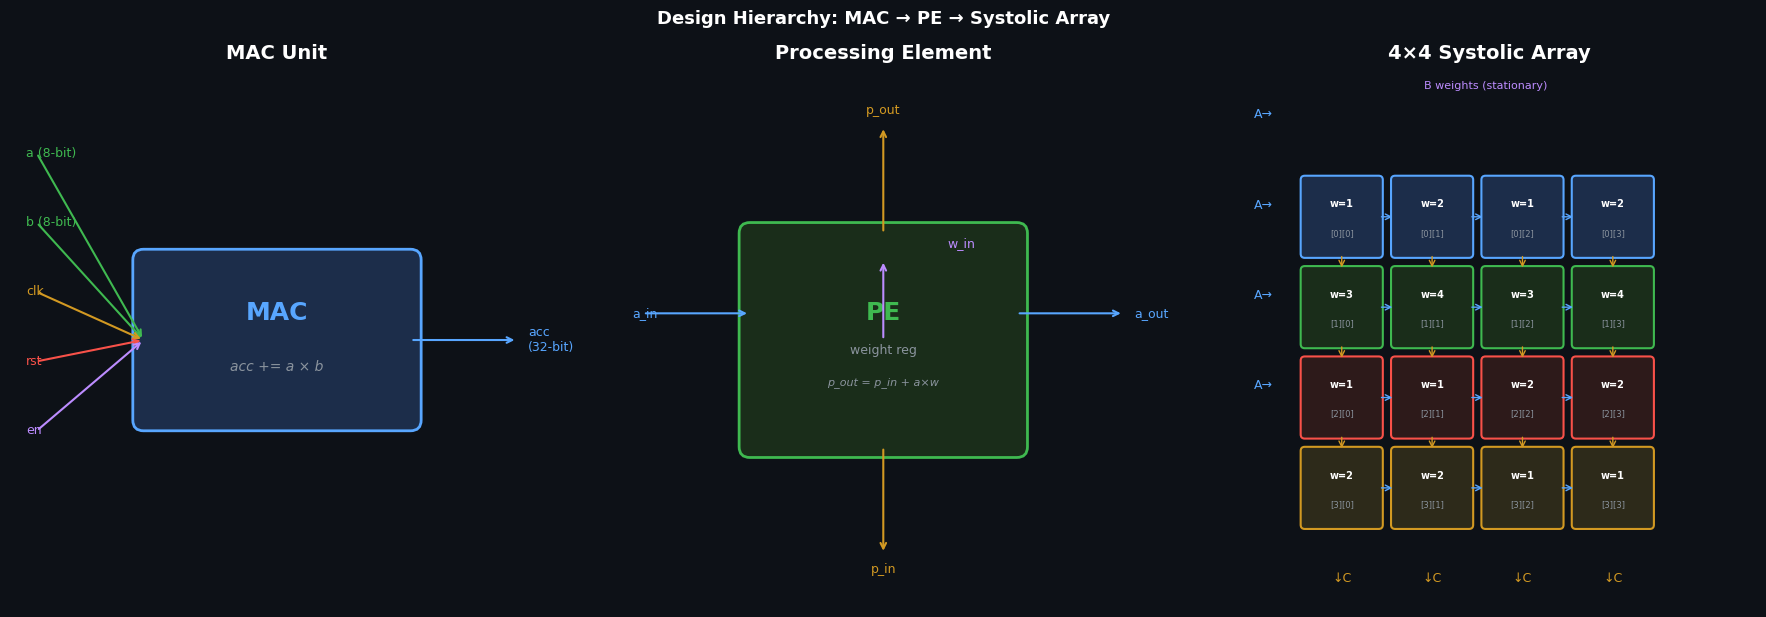

Architecture diagram generated


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#0d1117')

# Weight values for B4
B4 = np.array([[1,2,1,2],[3,4,3,4],[1,1,2,2],[2,2,1,1]])

# ── Panel 1: MAC unit ─────────────────────────────────────────
ax = axes[0]
ax.set_facecolor('#0d1117')
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('MAC Unit', color='white', fontsize=14, fontweight='bold', pad=10)

mac_box = patches.FancyBboxPatch((2.5, 3.5), 5, 3,
    boxstyle="round,pad=0.2", linewidth=2,
    edgecolor='#58a6ff', facecolor='#1c2d4a')
ax.add_patch(mac_box)
ax.text(5, 5.5, 'MAC', color='#58a6ff', fontsize=18,
        fontweight='bold', ha='center', va='center')
ax.text(5, 4.5, 'acc += a × b', color='#8b949e', fontsize=10,
        ha='center', va='center', fontstyle='italic')

# Inputs
for y, label, color in [(8.5,'a (8-bit)','#3fb950'), (7.2,'b (8-bit)','#3fb950'),
                          (5.9,'clk','#d29922'), (4.6,'rst','#f85149'),
                          (3.3,'en','#bc8cff')]:
    ax.annotate('', xy=(2.5, 5), xytext=(0.5, y),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5))
    ax.text(0.3, y, label, color=color, fontsize=9, ha='left', va='center')

# Output
ax.annotate('', xy=(9.5, 5), xytext=(7.5, 5),
            arrowprops=dict(arrowstyle='->', color='#58a6ff', lw=1.5))
ax.text(9.7, 5, 'acc\n(32-bit)', color='#58a6ff', fontsize=9,
        ha='left', va='center')

# ── Panel 2: PE ───────────────────────────────────────────────
ax = axes[1]
ax.set_facecolor('#0d1117')
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Processing Element', color='white', fontsize=14,
             fontweight='bold', pad=10)

pe_box = patches.FancyBboxPatch((2.5, 3), 5, 4,
    boxstyle="round,pad=0.2", linewidth=2,
    edgecolor='#3fb950', facecolor='#1a2d1a')
ax.add_patch(pe_box)
ax.text(5, 5.5, 'PE', color='#3fb950', fontsize=18,
        fontweight='bold', ha='center', va='center')
ax.text(5, 4.8, 'weight reg', color='#8b949e', fontsize=9,
        ha='center', va='center')
ax.text(5, 4.2, 'p_out = p_in + a×w', color='#8b949e', fontsize=8,
        ha='center', va='center', fontstyle='italic')

ax.annotate('', xy=(2.5, 5.5), xytext=(0.5, 5.5),
            arrowprops=dict(arrowstyle='->', color='#58a6ff', lw=1.5))
ax.text(0.3, 5.5, 'a_in', color='#58a6ff', fontsize=9, ha='left', va='center')

ax.annotate('', xy=(9.5, 5.5), xytext=(7.5, 5.5),
            arrowprops=dict(arrowstyle='->', color='#58a6ff', lw=1.5))
ax.text(9.7, 5.5, 'a_out', color='#58a6ff', fontsize=9, ha='left', va='center')

ax.annotate('', xy=(5, 3), xytext=(5, 1),
            arrowprops=dict(arrowstyle='<-', color='#d29922', lw=1.5))
ax.text(5, 0.7, 'p_in', color='#d29922', fontsize=9, ha='center', va='center')

ax.annotate('', xy=(5, 9), xytext=(5, 7),
            arrowprops=dict(arrowstyle='->', color='#d29922', lw=1.5))
ax.text(5, 9.3, 'p_out', color='#d29922', fontsize=9, ha='center', va='center')

ax.annotate('', xy=(5, 5), xytext=(5, 6.5),
            arrowprops=dict(arrowstyle='<-', color='#bc8cff', lw=1.5))
ax.text(6.2, 6.8, 'w_in', color='#bc8cff', fontsize=9, ha='left', va='center')

# ── Panel 3: 4x4 systolic array ───────────────────────────────
ax = axes[2]
ax.set_facecolor('#0d1117')
ax.set_xlim(-1, 5.5)
ax.set_ylim(-1, 5.5)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('4×4 Systolic Array', color='white', fontsize=14,
             fontweight='bold', pad=10)

colors_row = ['#1c2d4a', '#1a2d1a', '#2d1a1a', '#2d2a1a']
edge_colors = ['#58a6ff', '#3fb950', '#f85149', '#d29922']

for row in range(4):
    for col in range(4):
        box = patches.FancyBboxPatch((col*1.1, (3-row)*1.1), 0.9, 0.9,
            boxstyle="round,pad=0.05", linewidth=1.5,
            edgecolor=edge_colors[row], facecolor=colors_row[row])
        ax.add_patch(box)
        ax.text(col*1.1+0.45, (3-row)*1.1+0.6,
                f'w={B4[row][col]}', color='white', fontsize=7,
                ha='center', va='center', fontweight='bold')
        ax.text(col*1.1+0.45, (3-row)*1.1+0.25,
                f'[{row}][{col}]', color='#8b949e', fontsize=6,
                ha='center', va='center')

        if col < 3:
            ax.annotate('', xy=((col+1)*1.1, (3-row)*1.1+0.45),
                        xytext=(col*1.1+0.9, (3-row)*1.1+0.45),
                        arrowprops=dict(arrowstyle='->', color='#58a6ff', lw=1))
        if row < 3:
            ax.annotate('', xy=(col*1.1+0.45, (3-row-1)*1.1+0.9),
                        xytext=(col*1.1+0.45, (3-row)*1.1),
                        arrowprops=dict(arrowstyle='->', color='#d29922', lw=1))

ax.text(-0.5, 4.95, 'A→', color='#58a6ff', fontsize=9, ha='center')
ax.text(-0.5, 3.85, 'A→', color='#58a6ff', fontsize=9, ha='center')
ax.text(-0.5, 2.75, 'A→', color='#58a6ff', fontsize=9, ha='center')
ax.text(-0.5, 1.65, 'A→', color='#58a6ff', fontsize=9, ha='center')

ax.text(0.45, -0.7, '↓C', color='#d29922', fontsize=9, ha='center')
ax.text(1.55, -0.7, '↓C', color='#d29922', fontsize=9, ha='center')
ax.text(2.65, -0.7, '↓C', color='#d29922', fontsize=9, ha='center')
ax.text(3.75, -0.7, '↓C', color='#d29922', fontsize=9, ha='center')

ax.text(2.2, 5.3, 'B weights (stationary)', color='#bc8cff',
        fontsize=8, ha='center')

plt.suptitle('Design Hierarchy: MAC → PE → Systolic Array',
             color='white', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('architecture.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print("Architecture diagram generated")

## 4. RTL Implementation

All Verilog modules written below and saved to disk for simulation.

In [ ]:
import os
os.makedirs('rtl', exist_ok=True)
os.makedirs('tb', exist_ok=True)
os.makedirs('sim', exist_ok=True)

# mac.v
with open('rtl/mac.v', 'w') as f:
    f.write('''\
module mac #(
    parameter DATA_WIDTH = 8,
    parameter ACC_WIDTH  = 32
)(
    input  wire                          clk,
    input  wire                          rst,
    input  wire                          en,
    input  wire signed [DATA_WIDTH-1:0]  a,
    input  wire signed [DATA_WIDTH-1:0]  b,
    output reg  signed [ACC_WIDTH-1:0]   acc
);
    always @(posedge clk) begin
        if (rst)
            acc <= 0;
        else if (en)
            acc <= acc + (a * b);
    end
endmodule
''')

# pe_pipeline.v
with open('rtl/pe_pipeline.v', 'w') as f:
    f.write('''\
module pe_pipeline #(
    parameter DATA_WIDTH  = 8,
    parameter ACC_WIDTH   = 32,
    parameter PIPE_DEPTH  = 1
)(
    input  wire                          clk,
    input  wire                          rst,
    input  wire                          en,
    input  wire signed [DATA_WIDTH-1:0]  a_in,
    input  wire signed [DATA_WIDTH-1:0]  w_in,
    input  wire signed [ACC_WIDTH-1:0]   p_in,
    output reg  signed [DATA_WIDTH-1:0]  a_out,
    output reg  signed [ACC_WIDTH-1:0]   p_out
);
    reg signed [DATA_WIDTH-1:0] weight;

    always @(posedge clk) begin
        if (rst) begin
            weight <= 0;
            a_out  <= 0;
            p_out  <= 0;
        end else if (en) begin
            weight <= w_in;
            a_out  <= a_in;
            p_out  <= p_in + (a_in * weight);
        end
    end
endmodule
''')

# systolic_array.v
with open('rtl/systolic_array.v', 'w') as f:
    f.write('''\
module systolic_array #(
    parameter N          = 4,
    parameter DATA_WIDTH = 8,
    parameter ACC_WIDTH  = 32
)(
    input  wire                          clk,
    input  wire                          rst,
    input  wire                          en,
    input  wire [N*DATA_WIDTH-1:0]       a_row,
    input  wire [N*N*DATA_WIDTH-1:0]     weights,
    output wire [N*ACC_WIDTH-1:0]        result
);
    wire signed [DATA_WIDTH-1:0] a_wire [0:(N*(N+1))-1];
    wire signed [ACC_WIDTH-1:0]  p_wire [0:((N+1)*N)-1];

    genvar i;
    generate
        for (i = 0; i < N; i = i + 1) begin : connect_inputs
            assign a_wire[i*(N+1)] = a_row[i*DATA_WIDTH +: DATA_WIDTH];
        end
    endgenerate

    genvar j;
    generate
        for (j = 0; j < N; j = j + 1) begin : connect_zeros
            assign p_wire[j] = 0;
        end
    endgenerate

    genvar k;
    generate
        for (k = 0; k < N; k = k + 1) begin : connect_outputs
            assign result[k*ACC_WIDTH +: ACC_WIDTH] = p_wire[N*N + k];
        end
    endgenerate

    genvar row, col;
    generate
        for (row = 0; row < N; row = row + 1) begin : pe_rows
            for (col = 0; col < N; col = col + 1) begin : pe_cols
                pe_pipeline #(
                    .DATA_WIDTH(DATA_WIDTH),
                    .ACC_WIDTH(ACC_WIDTH),
                    .PIPE_DEPTH(1)
                ) pe_inst (
                    .clk   (clk),
                    .rst   (rst),
                    .en    (en),
                    .a_in  (a_wire[row*(N+1) + col]),
                    .w_in  (weights[(row*N+col)*DATA_WIDTH +: DATA_WIDTH]),
                    .p_in  (p_wire[row*N + col]),
                    .a_out (a_wire[row*(N+1) + col + 1]),
                    .p_out (p_wire[(row+1)*N + col])
                );
            end
        end
    endgenerate
endmodule
''')

print("RTL files written:")
print("  rtl/mac.v")
print("  rtl/pe_pipeline.v")
print("  rtl/systolic_array.v")

RTL files written:
  rtl/mac.v
  rtl/pe_pipeline.v
  rtl/systolic_array.v


In [ ]:
# Write testbenches
with open('tb/tb_mac.v', 'w') as f:
    f.write('''\
`timescale 1ns/1ps
module tb_mac;
    reg clk, rst, en;
    reg  signed [7:0]  a, b;
    wire signed [31:0] acc;

    mac #(.DATA_WIDTH(8), .ACC_WIDTH(32)) DUT (
        .clk(clk), .rst(rst), .en(en), .a(a), .b(b), .acc(acc));

    initial clk = 0;
    always #5 clk = ~clk;

    initial begin
        rst = 1; en = 0; a = 0; b = 0; #20; rst = 0;
        en = 1; a = 1; b = 2; #10; a = 3; b = 4; #10; en = 0; #5;
        if (acc === 14) $display("PASS Test 1: acc = %0d", acc);
        else $display("FAIL Test 1: expected 14 got %0d", acc);
        rst = 1; #10; rst = 0; #5;
        if (acc === 0) $display("PASS Test 2: reset cleared acc");
        else $display("FAIL Test 2: expected 0 got %0d", acc);
        en = 1; a = 5; b = 5; #10; en = 0; a = 3; b = 3; #10; #5;
        if (acc === 25) $display("PASS Test 3: en=0 froze acc at %0d", acc);
        else $display("FAIL Test 3: expected 25 got %0d", acc);
        rst = 1; #10; rst = 0; en = 1; a = -2; b = 3; #10; en = 0; #5;
        if (acc === -6) $display("PASS Test 4: negative correct acc = %0d", acc);
        else $display("FAIL Test 4: expected -6 got %0d", acc);
        #20 $finish;
    end
endmodule
''')

with open('tb/tb_systolic_array.v', 'w') as f:
    f.write('''\
`timescale 1ns/1ps
module tb_systolic_array;
    reg clk, rst, en;
    reg [31:0]  a_row;
    reg [127:0] weights;
    wire [127:0] result;

    systolic_array #(.DATA_WIDTH(8), .ACC_WIDTH(32), .N(4)) DUT (
        .clk(clk), .rst(rst), .en(en),
        .a_row(a_row), .weights(weights), .result(result));

    initial clk = 0;
    always #5 clk = ~clk;

    initial begin
        rst = 1; en = 0; a_row = 0; weights = 0; #20; rst = 0;
        weights = {8\'d1,8\'d1,8\'d2,8\'d2,8\'d2,8\'d2,8\'d1,8\'d1,
                   8\'d4,8\'d3,8\'d4,8\'d3,8\'d2,8\'d1,8\'d2,8\'d1};
        en = 1; #10;
        a_row = {8\'d0,8\'d0,8\'d0,8\'d1}; #10;
        a_row = {8\'d0,8\'d0,8\'d2,8\'d0}; #10;
        a_row = {8\'d0,8\'d3,8\'d0,8\'d0}; #10;
        a_row = {8\'d4,8\'d0,8\'d0,8\'d0}; #10;
        a_row = 0;
      if (result[31:0]===32\'d18) $display("PASS C[0][0] = %0d",result[31:0]);
        else $display("FAIL C[0][0] expected 18 got %0d",result[31:0]);
        #10;
      if (result[63:32]===32\'d21) $display("PASS C[0][1] = %0d",result[63:32]);
        else $display("FAIL C[0][1] expected 21 got %0d",result[63:32]);
        #10;
      if (result[95:64]===32\'d17) $display("PASS C[0][2] = %0d",result[95:64]);
        else $display("FAIL C[0][2] expected 17 got %0d",result[95:64]);
        #10;
    if (result[127:96]===32\'d20) $display("PASS C[0][3] = %0d",result[127:96]);
        else $display("FAIL C[0][3] expected 20 got %0d",result[127:96]);
        #20 $finish;
    end
endmodule
''')

print("Testbench files written:")
print("  tb/tb_mac.v")
print("  tb/tb_systolic_array.v")

Testbench files written:
  tb/tb_mac.v
  tb/tb_systolic_array.v


## 5. Simulation and Verification

In [ ]:
import subprocess

def run_sim(tb_file, dut_files, out_name):
    files = [tb_file] + dut_files
    compile_cmd = ['iverilog', '-o', f'sim/{out_name}'] + files
    result = subprocess.run(compile_cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print(f"Compile error: {result.stderr}")
        return
    run_result = subprocess.run(['vvp', f'sim/{out_name}'],
                                capture_output=True, text=True)
    print(run_result.stdout)

print("=" * 50)
print("MAC Unit Testbench")
print("=" * 50)
run_sim('tb/tb_mac.v', ['rtl/mac.v'], 'tb_mac')

print("=" * 50)
print("Systolic Array Testbench")
print("=" * 50)
run_sim('tb/tb_systolic_array.v',
        ['rtl/systolic_array.v', 'rtl/pe_pipeline.v', 'rtl/mac.v'],
        'tb_systolic_array')

MAC Unit Testbench
PASS Test 1: acc = 14
PASS Test 2: reset cleared acc
PASS Test 3: en=0 froze acc at 25
PASS Test 4: negative correct acc = -6

Systolic Array Testbench
PASS C[0][0] = 18
PASS C[0][1] = 21
PASS C[0][2] = 17
PASS C[0][3] = 20



## 6. Physical Implementation — OpenLane on Sky130A

The design was synthesized and implemented using OpenLane v1.0.2 on the SkyWater 130nm PDK. The flow runs locally — results are presented below.

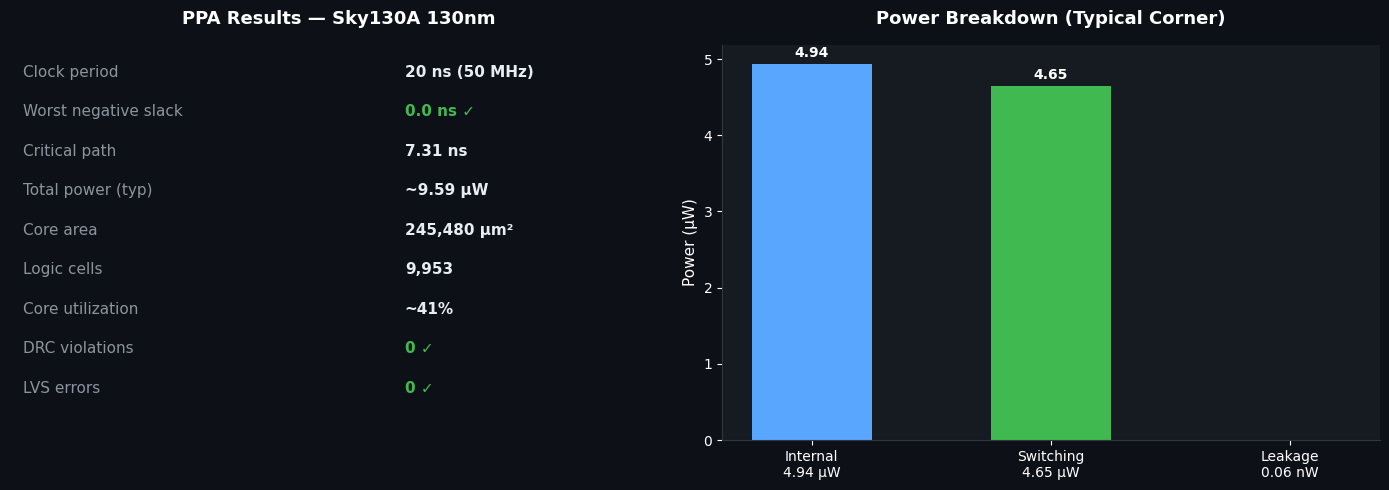


Key achievements:
✓ Timing closure at 50 MHz
✓ Zero DRC violations
✓ Zero LVS errors
✓ Production-ready layout on Sky130A


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d1117')

# PPA data
metrics = {
    'Clock period': '20 ns (50 MHz)',
    'Worst negative slack': '0.0 ns ✓',
    'Critical path': '7.31 ns',
    'Total power (typ)': '~9.59 µW',
    'Core area': '245,480 µm²',
    'Logic cells': '9,953',
    'Core utilization': '~41%',
    'DRC violations': '0 ✓',
    'LVS errors': '0 ✓',
}

ax = axes[0]
ax.set_facecolor('#0d1117')
ax.axis('off')
ax.set_title('PPA Results — Sky130A 130nm', color='white',
             fontsize=13, fontweight='bold', pad=15)

y = 0.95
for metric, value in metrics.items():
    color = '#3fb950' if '✓' in value else '#e6edf3'
    ax.text(0.02, y, metric, color='#8b949e', fontsize=11,
            transform=ax.transAxes, va='top')
    ax.text(0.6, y, value, color=color, fontsize=11,
            fontweight='bold', transform=ax.transAxes, va='top')
    y -= 0.1

# Power breakdown bar chart
ax2 = axes[1]
ax2.set_facecolor('#161b22')
ax2.set_title('Power Breakdown (Typical Corner)',
              color='white', fontsize=13, fontweight='bold', pad=15)

categories = ['Internal\n4.94 µW', 'Switching\n4.65 µW', 'Leakage\n0.06 nW']
values = [4.94, 4.65, 0.00006]
colors = ['#58a6ff', '#3fb950', '#d29922']
bars = ax2.bar(categories, values, color=colors, width=0.5, edgecolor='none')
ax2.set_facecolor('#161b22')
ax2.tick_params(colors='white')
ax2.spines['bottom'].set_color('#30363d')
ax2.spines['left'].set_color('#30363d')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_ylabel('Power (µW)', color='white', fontsize=11)
ax2.yaxis.label.set_color('white')
for label in ax2.get_xticklabels() + ax2.get_yticklabels():
    label.set_color('white')

for bar, val in zip(bars, values):
    if val > 0.01:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{val:.2f}', ha='center', va='bottom',
                color='white', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('ppa_results.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print("\nKey achievements:")
print("✓ Timing closure at 50 MHz")
print("✓ Zero DRC violations")
print("✓ Zero LVS errors")
print("✓ Production-ready layout on Sky130A")

## 7. Key Learnings and Design Decisions

### Why weight-stationary over output-stationary?

In ML inference the same model weights serve millions of requests. Loading weights once into PE registers and keeping them stationary minimises weight memory bandwidth — the dominant bottleneck for inference. This is the same choice Google made for TPU v1.

### Why 8-bit fixed-point?

Inference tolerates lower precision than training. 8-bit integers give 4× smaller multipliers vs 32-bit float, with acceptable accuracy for most inference workloads. The 32-bit accumulator prevents overflow across N multiply-accumulate operations.

### The pipeline timing insight

Each PE delays activations by one cycle before passing them right. This creates the data wavefront that aligns correct A and B values at each PE at the right time. Without this delay, all PEs in a row would receive the same activation simultaneously — producing incorrect results.

### Scalability

The entire design is parameterized by a single value N. Changing `parameter N = 4` to `parameter N = 256` produces a TPU-scale array — same architecture, same Verilog, 4096× more PEs, synthesized automatically via generate blocks.

### Connection to modern AI hardware

This 4×4 array implements the same primitive as:
- Google TPU v1: 256×256 = 65,536 MACs
- NVIDIA Blackwell Tensor Core: tiny systolic arrays inside each SM
- Intel Loihi (neuromorphic): MAC-based inference for continual learning

The gap between this design and production silicon is scale and precision — not architecture.

## 8. Tools and Reproducibility

| Tool | Version |
|------|---------|
| Icarus Verilog | 11.0 |
| GTKWave | 3.3.116 |
| OpenLane | v1.0.2 (ff5509f) |
| PDK | SkyWater Sky130A |
| Standard cell library | sky130_fd_sc_hd |
| Python | 3.x |
| NumPy | 1.26.4 |

All simulation code in this notebook is fully reproducible — run all cells in order to install tools, write RTL, compile, simulate, and view results.

GitHub: https://github.com/Needahh/matrix_accelerator



## 9 Physical Layout — GDS View

The image below shows the placed and routed layout of the systolic array on Sky130A 130nm. The dense green and yellow fill represents Metal 2 and Metal 3 routing layers across 9,953 standard cells at ~41% core utilization.

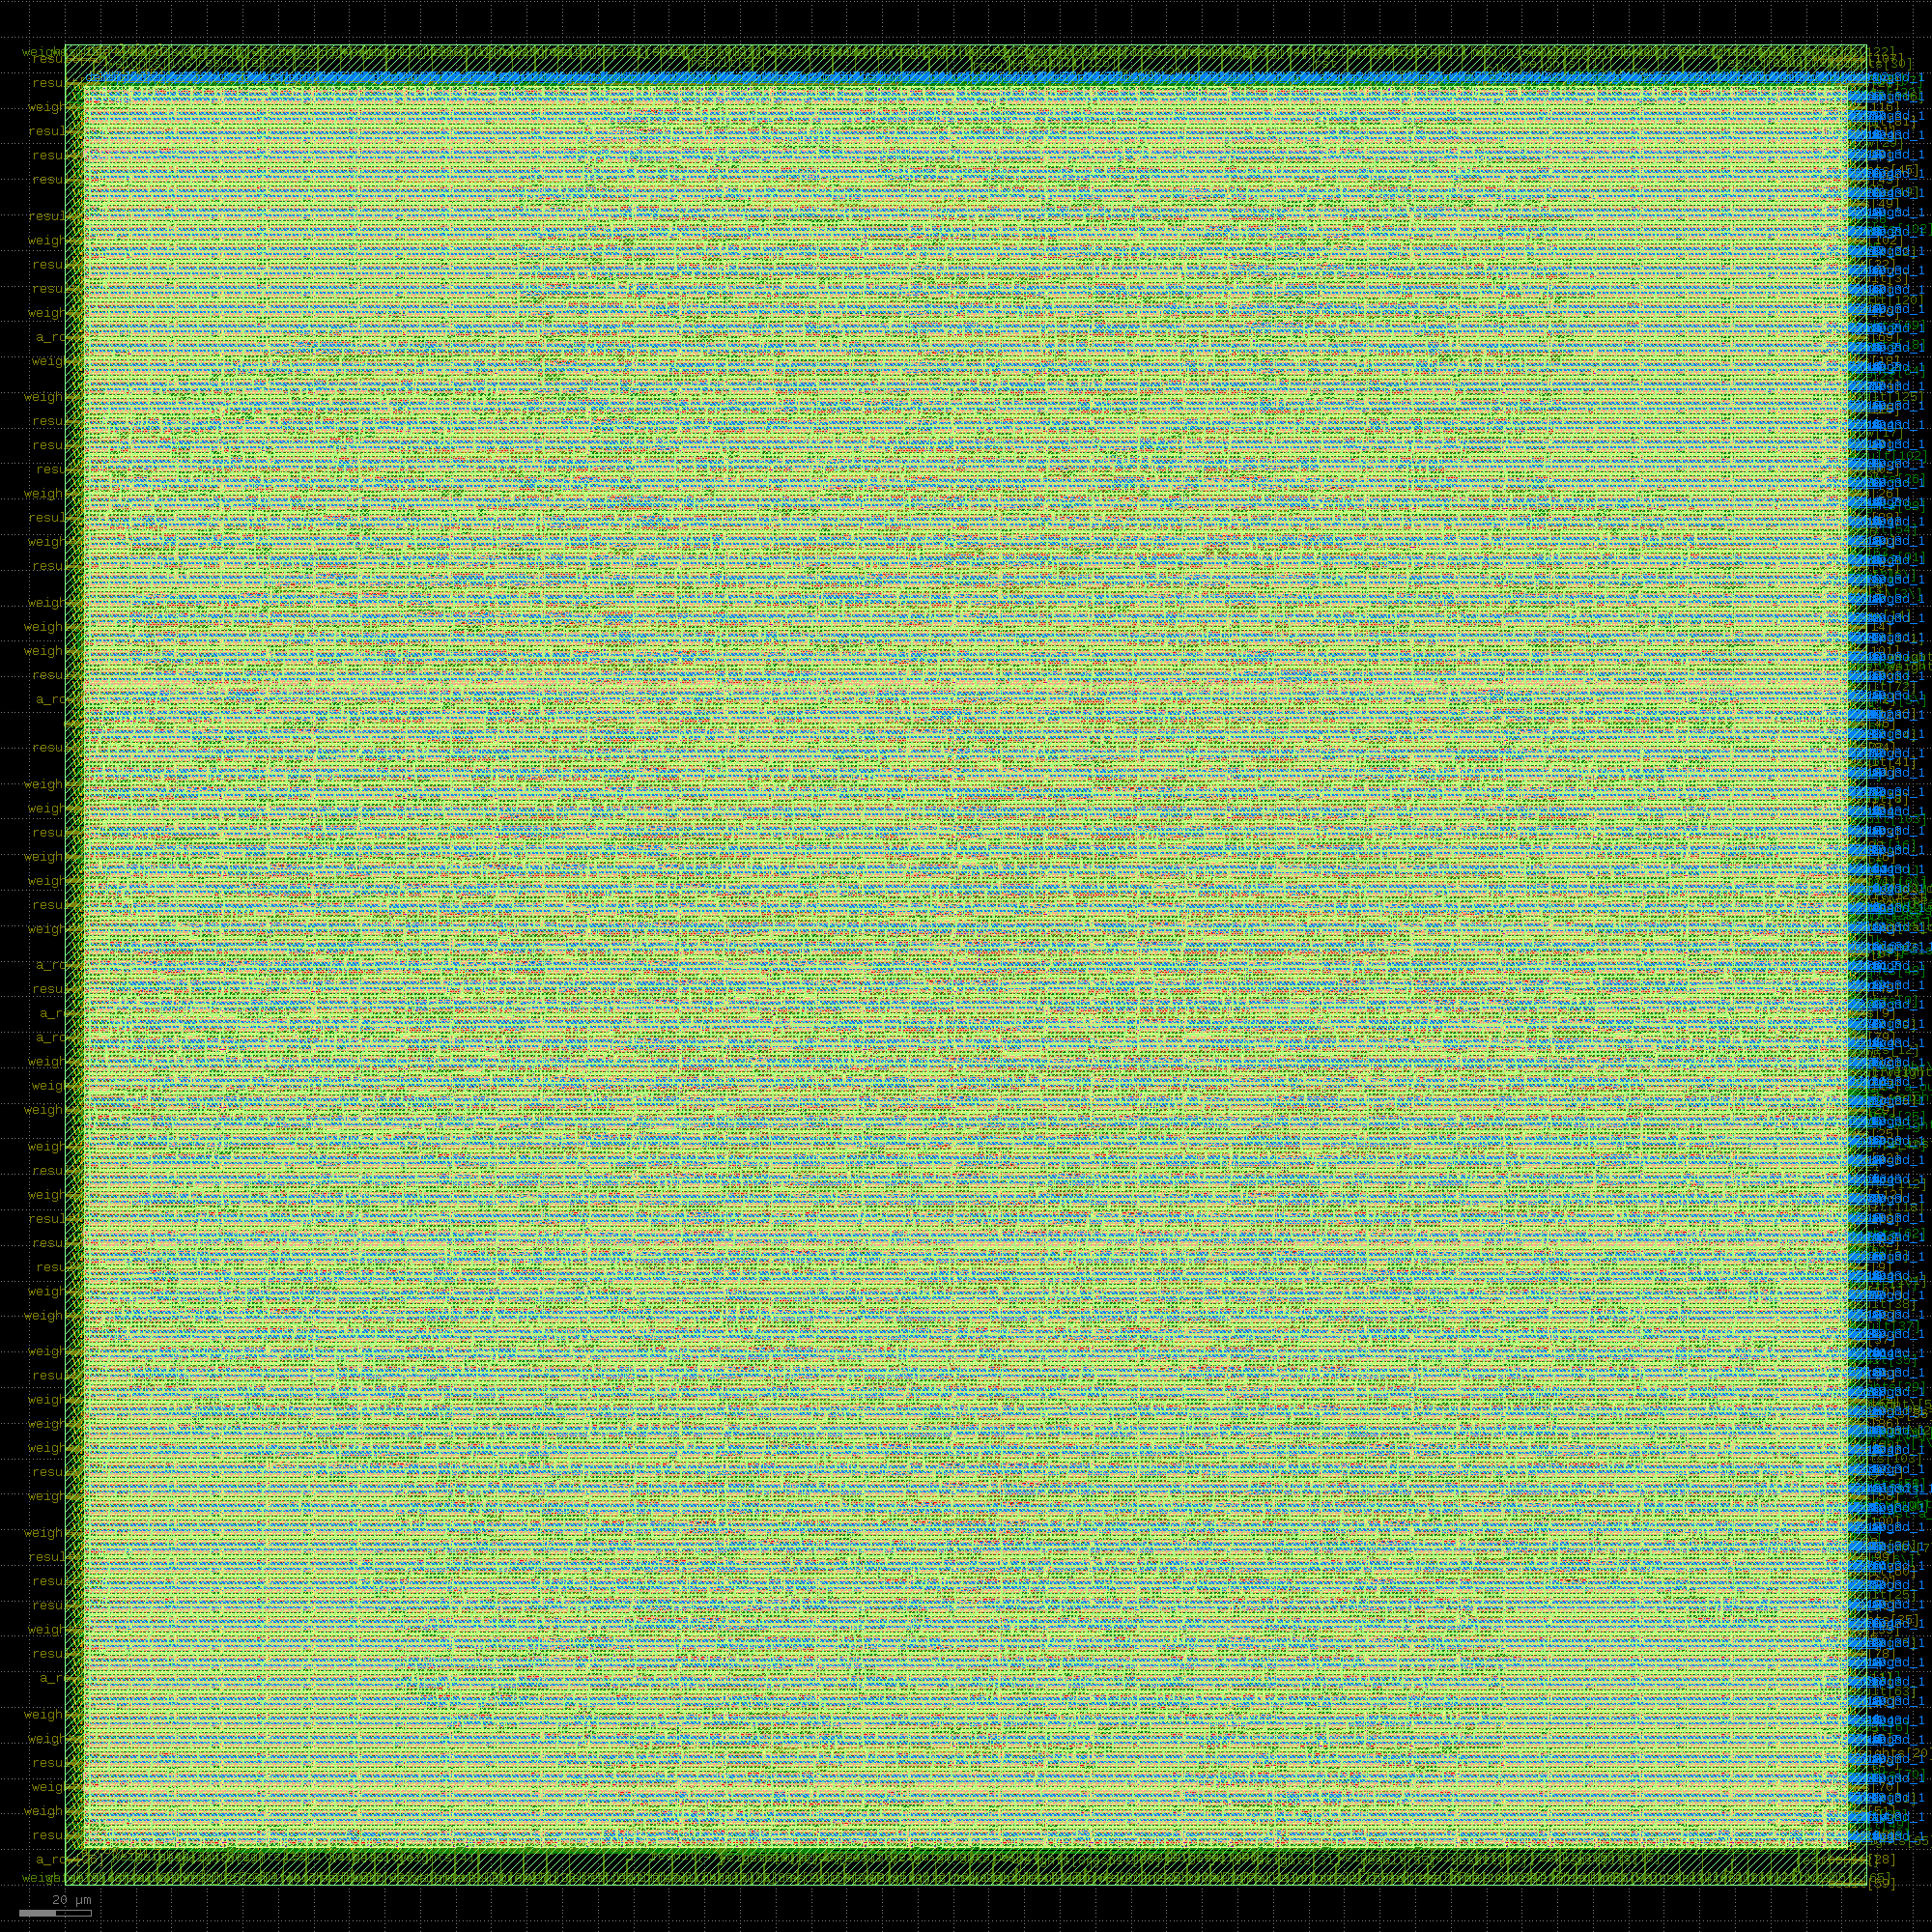

In [ ]:
from IPython.display import Image, display

display(Image('systolic_array_gds.png', width=700))